# Twitter Hate Speech Classification — NLP Portfolio
## 6CS012 Final Portfolio | Part III: Language Modelling

Three recurrent neural networks are trained to distinguish between hate speech, offensive language, and neutral tweets from a labelled Twitter corpus.

| Model | Architecture | Embeddings |
|-------|-------------|-----------|
| M1 | Simple RNN | Trainable (random init) |
| M2 | LSTM | Trainable (random init) |
| M3 | Bidirectional LSTM | Word2Vec (Google News 300d) |

> **Note:** The label `hate speec` is a known typo in the source dataset and is preserved as-is throughout.

---

## Section 1 — Environment Setup and Data Loading

In [ ]:
# Dependencies: numpy pinned for gensim compatibility; gradio for the GUI
!pip install -q numpy==1.23.5 gensim gradio
print("Environment ready — restart the runtime if Colab prompts you, then re-run.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 45.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
Environment ready — restart the runtime if Colab prompts you, then re-run.


In [ ]:
import os
import re
import time
import random
import html
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',  quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print(f"TensorFlow version : {tf.__version__}")
print(f"GPUs detected      : {len(tf.config.list_physical_devices('GPU'))}")

TensorFlow version : 2.20.0
GPUs detected      : 0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = '/content/drive/MyDrive/hatevsoffensive_language.csv'
# Update the path above if you stored the file elsewhere in Drive

raw_df = pd.read_csv(DATASET_PATH)
print(f"Dataset shape  : {raw_df.shape}")
print(f"Columns        : {raw_df.columns.tolist()}")
print(f"\nPreview:")
raw_df.head(5)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape  : (24783, 2)
Columns        : ['label', 'text']

Preview:


,label,text
0,neither,!!! RT @mayasolovely: As a woman you shouldn't...
1,offensive language,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,offensive language,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,offensive language,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,offensive language,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


Label frequencies:
 label
offensive language    19190
neither                4163
hate speec             1430
Name: count, dtype: int64

Proportions (%):
 label
offensive language    77.43
neither               16.80
hate speec             5.77
Name: count, dtype: float64


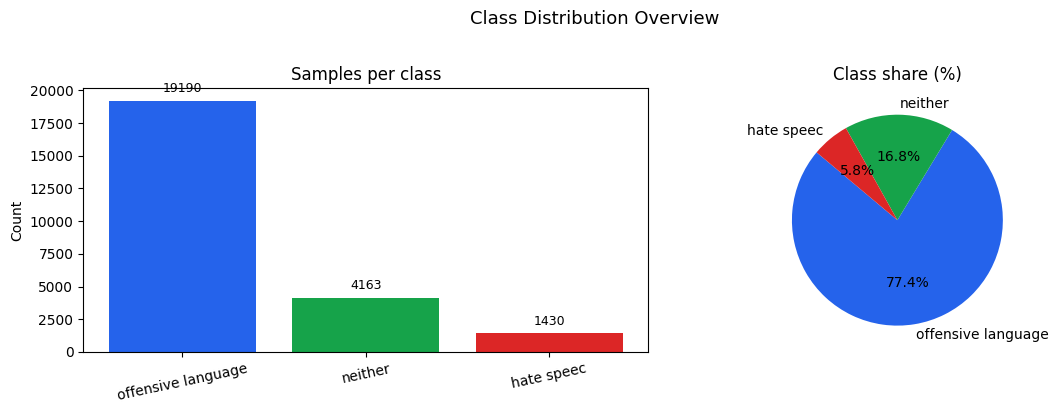


Imbalance warning: minority class is only 5.8% of data.
Class weighting will be applied during model training to compensate.


In [ ]:
label_counts = raw_df['label'].value_counts()
print("Label frequencies:\n", label_counts)
print("\nProportions (%):\n", (label_counts / label_counts.sum() * 100).round(2))

# Bar + Pie side by side
fig, (ax_bar, ax_pie) = plt.subplots(1, 2, figsize=(12, 4))

palette = ['#2563EB' if v == label_counts.max() else
           '#DC2626' if v == label_counts.min() else
           '#16A34A' for v in label_counts.values]

bar_rects = ax_bar.bar(label_counts.index, label_counts.values, color=palette)
ax_bar.bar_label(bar_rects, padding=4, fontsize=9)
ax_bar.set_title('Samples per class')
ax_bar.set_ylabel('Count')
ax_bar.tick_params(axis='x', rotation=12)

ax_pie.pie(
    label_counts.values,
    labels=label_counts.index,
    autopct='%1.1f%%',
    colors=palette,
    startangle=140,
)
ax_pie.set_title('Class share (%)')

plt.suptitle('Class Distribution Overview', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

minority_pct = label_counts.min() / label_counts.sum() * 100
print(f"\nImbalance warning: minority class is only {minority_pct:.1f}% of data.")
print("Class weighting will be applied during model training to compensate.")

Raw text length statistics:
       n_chars  n_words
count  24783.0  24783.0
mean      85.4     14.1
std       41.5      6.8
min        5.0      1.0
25%       52.0      9.0
50%       81.0     13.0
75%      119.0     19.0
max      754.0     52.0


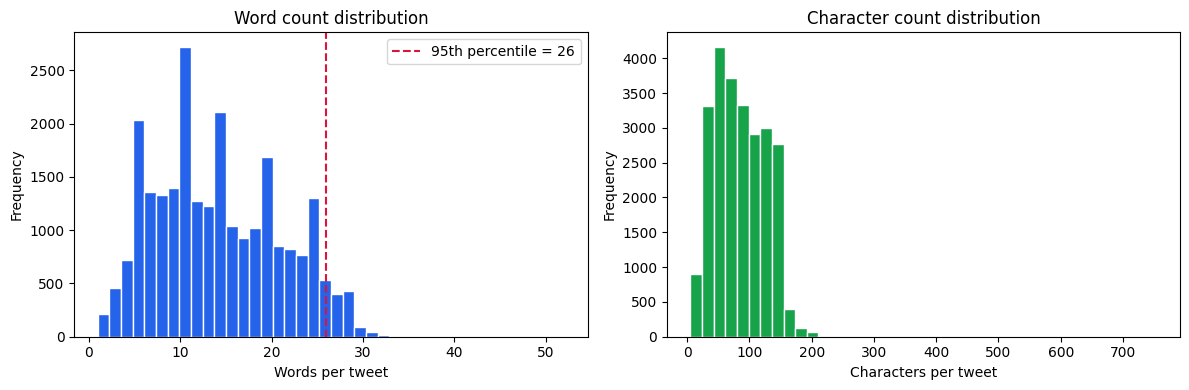

In [ ]:
raw_df['n_chars'] = raw_df['text'].str.len()
raw_df['n_words'] = raw_df['text'].str.split().str.len()

print("Raw text length statistics:")
print(raw_df[['n_chars', 'n_words']].describe().round(1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

p95_words = raw_df['n_words'].quantile(0.95)
ax1.hist(raw_df['n_words'], bins=40, color='#2563EB', edgecolor='white')
ax1.axvline(p95_words, color='crimson', linestyle='--',
            label=f'95th percentile = {p95_words:.0f}')
ax1.set_title('Word count distribution')
ax1.set_xlabel('Words per tweet')
ax1.set_ylabel('Frequency')
ax1.legend()

ax2.hist(raw_df['n_chars'], bins=40, color='#16A34A', edgecolor='white')
ax2.set_title('Character count distribution')
ax2.set_xlabel('Characters per tweet')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 2 — Text Cleaning and Preprocessing

Twitter data contains considerable noise that must be removed before modelling:

| Step | Operation | Rationale |
|------|-----------|-----------|
| 1 | Decode HTML entities | Converts `&amp;`, `&#128569;` etc. to readable form |
| 2 | Lowercase | Ensures case-insensitive token matching |
| 3 | Remove URLs / mentions / RT tags | Non-semantic noise |
| 4 | Strip `#` prefix from hashtags | Keeps the word, removes the symbol |
| 5 | Expand contractions | `can't` → `cannot` avoids split tokens |
| 6 | Remove non-alphabetic characters | Numerals and punctuation add no signal |
| 7 | Remove stopwords | High-frequency function words |
| 8 | Lemmatize | Reduces inflected forms to base (running → run) |

In [ ]:
STOPWORDS = set(stopwords.words('english'))
lemmatiser = WordNetLemmatizer()

CONTRACTION_MAP = {
    "don't": "do not",   "can't": "cannot",     "won't": "will not",
    "i'm":   "i am",     "you're": "you are",   "he's":  "he is",
    "she's": "she is",   "it's":   "it is",     "we're": "we are",
    "they're": "they are", "i've": "i have",    "you've": "you have",
    "we've": "we have",  "they've": "they have", "i'll":  "i will",
    "you'll": "you will", "he'll": "he will",   "she'll": "she will",
    "we'll": "we will",  "they'll": "they will", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not",   "weren't": "were not",
    "haven't": "have not", "hasn't": "has not", "hadn't": "had not",
    "doesn't": "does not", "didn't": "did not", "wouldn't": "would not",
    "shouldn't": "should not", "couldn't": "could not",
    "mustn't": "must not", "let's": "let us",   "that's": "that is",
    "what's": "what is",  "where's": "where is", "there's": "there is",
    "here's": "here is",  "y'all": "you all",   "ain't": "is not",
}


def preprocess_tweet(raw_text):
    """Full cleaning pipeline for a single tweet string."""
    if not isinstance(raw_text, str):
        return ""

    # 1. HTML entity decoding
    txt = html.unescape(raw_text)
    # 2. Lowercase
    txt = txt.lower()
    # 3. Strip URLs
    txt = re.sub(r'http\S+|www\.\S+', ' ', txt)
    # 4. Strip @mentions
    txt = re.sub(r'@\w+', ' ', txt)
    # 5. Strip retweet marker
    txt = re.sub(r'\brt\b', ' ', txt)
    # 6. Remove # but keep the hashtag word
    txt = re.sub(r'#', ' ', txt)
    # 7. Expand contractions
    for short, expanded in CONTRACTION_MAP.items():
        txt = txt.replace(short, expanded)
    # 8. Keep only alphabetic characters
    txt = re.sub(r'[^a-z\s]', ' ', txt)
    # 9. Collapse extra whitespace
    txt = re.sub(r'\s+', ' ', txt).strip()
    # 10. Stopword removal + lemmatisation
    tokens = [
        lemmatiser.lemmatize(token)
        for token in txt.split()
        if token not in STOPWORDS and len(token) > 1
    ]
    return ' '.join(tokens)


# Sanity check on a few raw tweets before applying to the full corpus
sample_tweets = raw_df['text'].sample(3, random_state=7).tolist()
print("Preprocessing sanity check")
print("=" * 65)
for tw in sample_tweets:
    print(f"  ORIGINAL : {tw[:100]}")
    print(f"  CLEANED  : {preprocess_tweet(tw)[:100]}")
    print()

Preprocessing sanity check
  ORIGINAL : RT @FriendlyAssh0le: If I've ever offended you, im sorry..

.

.

.

.

.

.

.

.

.

.

that you'r
  CLEANED  : ever offended im sorry sensitive lil bitch

  ORIGINAL : RT @JesusIsAJerk: On my way to fuck your bitch. http://t.co/aNZngPNmLS
  CLEANED  : way fuck bitch

  ORIGINAL : And I lick it after you clean it , eat pussy like a dyke but I fuck like a demon &#128545;&#128166;
  CLEANED  : lick clean eat pussy like dyke fuck like demon



In [ ]:
print("Applying cleaning pipeline to full dataset...")
t0 = time.time()
raw_df['cleaned_text'] = raw_df['text'].apply(preprocess_tweet)
print(f"Completed in {time.time() - t0:.1f}s")

# Remove rows where the entire tweet collapsed to an empty string
n_before = len(raw_df)
df = raw_df[raw_df['cleaned_text'].str.len() > 0].reset_index(drop=True)
print(f"Removed {n_before - len(df)} empty rows after cleaning.")
print(f"Usable rows: {len(df)}")

df['cleaned_word_count'] = df['cleaned_text'].str.split().str.len()
print("\nCleaned text word counts:")
print(df['cleaned_word_count'].describe().round(1))

Applying cleaning pipeline to full dataset...
Completed in 2.6s
Removed 2 empty rows after cleaning.
Usable rows: 24781

Cleaned text word counts:
count    24781.0
mean         7.3
std          3.7
min          1.0
25%          4.0
50%          7.0
75%         10.0
max         27.0
Name: cleaned_word_count, dtype: float64


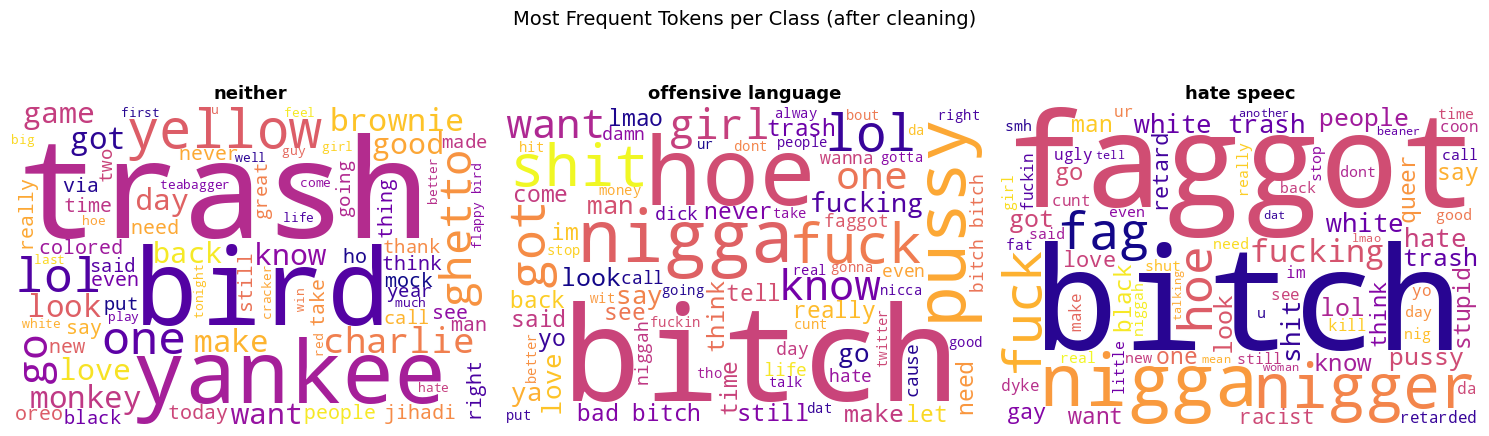

In [ ]:
from wordcloud import WordCloud

unique_labels = df['label'].unique()
fig, axes = plt.subplots(1, len(unique_labels), figsize=(5 * len(unique_labels), 5))

for ax, label_name in zip(axes, unique_labels):
    corpus = ' '.join(df.loc[df['label'] == label_name, 'cleaned_text'].tolist())
    wc = WordCloud(
        width=480, height=320,
        background_color='white',
        max_words=75,
        colormap='plasma',
    ).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(label_name, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('Most Frequent Tokens per Class (after cleaning)', fontsize=14)
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

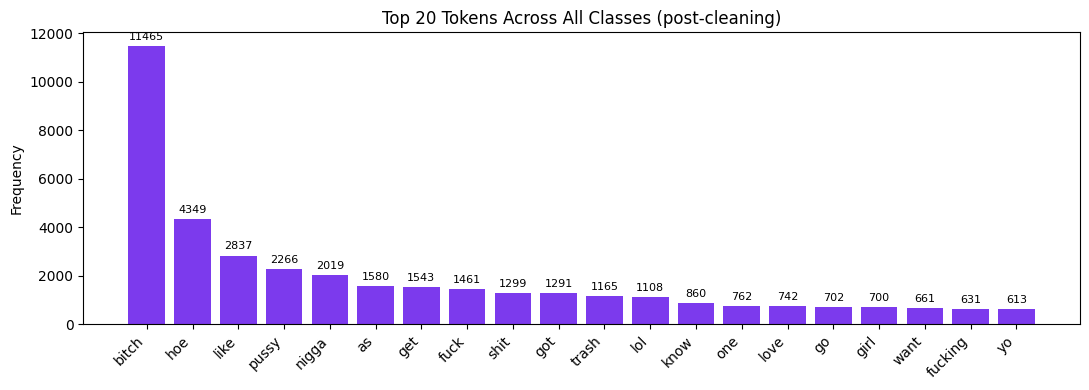

In [ ]:
all_tokens = ' '.join(df['cleaned_text'].tolist()).split()
token_freq = Counter(all_tokens).most_common(20)
top_tokens, top_freqs = zip(*token_freq)

plt.figure(figsize=(11, 4))
rects = plt.bar(top_tokens, top_freqs, color='#7C3AED')
plt.bar_label(rects, padding=3, fontsize=8)
plt.title('Top 20 Tokens Across All Classes (post-cleaning)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 3 — Label Encoding, Tokenisation, Train/Test Split, and Padding

Steps performed in this section:

1. Encode the three string labels to integers, then to one-hot vectors.
2. **Stratified 80/20 split** — preserves class proportions in both partitions.
3. Fit a Keras `Tokenizer` on training text only (no test-set leakage).
4. Convert text to integer sequences.
5. Set `MAX_SEQ_LEN` as the **95th percentile** of training sequence lengths — this keeps 95% of tweets intact and avoids inflating the embedding matrix with padding from extreme outliers.

In [ ]:
label_encoder = LabelEncoder()
y_int  = label_encoder.fit_transform(df['label'])
y_ohe  = to_categorical(y_int, num_classes=3)

print("Label → integer mapping:")
for idx, cls_name in enumerate(label_encoder.classes_):
    print(f"  {idx}  →  {cls_name}")

# Stratified split preserves the minority-class ratio
texts_train, texts_test, y_train, y_test = train_test_split(
    df['cleaned_text'].values,
    y_ohe,
    test_size=0.20,
    stratify=y_int,
    random_state=RANDOM_STATE,
)

print(f"\nTraining samples : {len(texts_train)}")
print(f"Test samples     : {len(texts_test)}")

Label → integer mapping:
  0  →  hate speec
  1  →  neither
  2  →  offensive language

Training samples : 19824
Test samples     : 4957


In [ ]:
MAX_VOCAB  = 10000    # cap vocabulary at the 10K most frequent tokens
OOV_MARKER = '<OOV>'  # token for out-of-vocabulary words at inference time

tok = Tokenizer(num_words=MAX_VOCAB, oov_token=OOV_MARKER)
tok.fit_on_texts(texts_train)          # fit on TRAIN only — no leakage

vocab_index  = tok.word_index
VOCAB_IN_USE = min(MAX_VOCAB, len(vocab_index) + 1)

print(f"Unique tokens in training corpus : {len(vocab_index):,}")
print(f"Vocabulary size used by models   : {VOCAB_IN_USE:,}")

# Text → integer sequences
train_seqs = tok.texts_to_sequences(texts_train)
test_seqs  = tok.texts_to_sequences(texts_test)

Unique tokens in training corpus : 15,993
Vocabulary size used by models   : 10,000


In [ ]:
train_lengths = [len(s) for s in train_seqs]

# Choose padding length from the 95th percentile to avoid extremes
MAX_SEQ_LEN = int(np.percentile(train_lengths, 95))

print("Training sequence length percentiles:")
for pct in [50, 75, 95, 99]:
    val = np.percentile(train_lengths, pct)
    marker = "  ← MAX_SEQ_LEN chosen here" if pct == 95 else ""
    print(f"  {pct}th : {val:.0f}{marker}")
print(f"  max  : {max(train_lengths)}")
print(f"\nMAX_SEQ_LEN = {MAX_SEQ_LEN}")

# Post-padding and post-truncation are standard for tweet-length text
X_train = pad_sequences(train_seqs, maxlen=MAX_SEQ_LEN, padding='post', truncating='post')
X_test  = pad_sequences(test_seqs,  maxlen=MAX_SEQ_LEN, padding='post', truncating='post')

print(f"\nPadded array shapes:")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_train : {y_train.shape}")
print(f"  y_test  : {y_test.shape}")

Training sequence length percentiles:
  50th : 7
  75th : 10
  95th : 14  ← MAX_SEQ_LEN chosen here
  99th : 16
  max  : 27

MAX_SEQ_LEN = 14

Padded array shapes:
  X_train : (19824, 14)
  X_test  : (4957, 14)
  y_train : (19824, 3)
  y_test  : (4957, 3)


## Section 4 — Handling Class Imbalance via Sample Weighting

The `hate speec` class makes up less than 6% of the dataset. Without compensation, all three models collapse to predicting the majority class and achieve misleading accuracy.

`compute_class_weight('balanced', ...)` produces weights inversely proportional to class frequency. Since the raw balanced weights aggressively over-predict the minority class (very high recall, very low precision), we apply a **square-root softening** that moderates the spread while still upweighting the minority class meaningfully.

In [ ]:
y_train_labels = np.argmax(y_train, axis=1)

# Raw balanced weights
raw_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels,
)

# Square-root softening reduces the minority/majority ratio
# e.g. from 5.78× down to ~2.40× — better precision/recall balance
softened_weights = np.sqrt(raw_weights)
softened_weights = softened_weights / softened_weights.mean()   # normalise

sample_weights_dict = {i: float(w) for i, w in enumerate(softened_weights)}

print(f"{'Label':<22} {'N (train)':>10} {'balanced':>10} {'sqrt-norm':>10}")
print("-" * 55)
for i, cls_name in enumerate(label_encoder.classes_):
    n = (y_train_labels == i).sum()
    print(f"{cls_name:<22} {n:>10} {raw_weights[i]:>10.3f} {softened_weights[i]:>10.3f}")

print("\nSoftened (sqrt-normalised) weights applied during training.")

Label                   N (train)   balanced  sqrt-norm
-------------------------------------------------------
hate speec                   1144      5.776      1.614
neither                      3329      1.985      0.946
offensive language          15351      0.430      0.440

Softened (sqrt-normalised) weights applied during training.


## Section 5 — Model 1: Simple RNN with Trainable Embedding

The simplest recurrent architecture serves as a baseline. `SimpleRNN` accumulates a hidden state across timesteps but is prone to the vanishing gradient problem, making it difficult to learn dependencies beyond a few tokens. Both the embedding and recurrent weights are learned from scratch on this dataset.

In [ ]:
EMBED_SIZE = 100   # dimensionality of the learned token embeddings

def construct_simple_rnn(vocab_size, embed_dim, seq_len):
    model = Sequential(name='SimpleRNN_Baseline')
    model.add(layers.Input(shape=(seq_len,)))
    model.add(layers.Embedding(input_dim=vocab_size, output_dim=embed_dim))
    model.add(layers.SimpleRNN(64, dropout=0.3, recurrent_dropout=0.0))
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(3, activation='softmax'))
    return model

model1 = construct_simple_rnn(VOCAB_IN_USE, EMBED_SIZE, MAX_SEQ_LEN)
model1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
model1.summary()

Model: "SimpleRNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 14, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,012,739 (3.86 MB)

 Trainable params: 1,012,739 (3.86 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Shared callbacks — reused for all three models
training_callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

t_start = time.time()
hist_m1 = model1.fit(
    X_train, y_train,
    validation_split=0.10,
    epochs=15,
    batch_size=64,
    class_weight=sample_weights_dict,
    callbacks=training_callbacks,
    verbose=1,
)
time_m1 = time.time() - t_start
print(f"\nModel 1 training completed in {time_m1 / 60:.2f} minutes.")

Epoch 1/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.8290 - loss: 0.3934 - val_accuracy: 0.8719 - val_loss: 0.3524 - learning_rate: 0.0010
Epoch 2/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8922 - loss: 0.2420 - val_accuracy: 0.8734 - val_loss: 0.3505 - learning_rate: 0.0010
Epoch 3/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9171 - loss: 0.1784 - val_accuracy: 0.8830 - val_loss: 0.3381 - learning_rate: 0.0010
Epoch 4/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9446 - loss: 0.1271 - val_accuracy: 0.8633 - val_loss: 0.4128 - learning_rate: 0.0010
Epoch 5/15
278/279 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9522 - loss: 0.1061
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
279/279 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9568 - loss: 0.0965 - val_accuracy: 0.8714 - val_loss: 0.4501 - learning_rate: 0.0010
Epoch 6/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9732 - loss: 0.0

In [ ]:
# ─── Shared utility functions ───────────────────────────────────────────────

def plot_training_curves(history, model_label):
    """Plot loss and accuracy curves for a fitted Keras model."""
    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))

    ax_loss.plot(history.history['loss'],     label='Training',   linewidth=2)
    ax_loss.plot(history.history['val_loss'], label='Validation', linewidth=2)
    ax_loss.set_title(f'{model_label} — Cross-entropy Loss')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    ax_loss.grid(alpha=0.25)

    ax_acc.plot(history.history['accuracy'],     label='Training',   linewidth=2)
    ax_acc.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
    ax_acc.set_title(f'{model_label} — Accuracy')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()
    ax_acc.grid(alpha=0.25)

    plt.tight_layout()
    fname = f"curves_{model_label.lower().replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()


def run_evaluation(model, X_data, y_onehot, model_label):
    """Evaluate a model and display accuracy, classification report, confusion matrix."""
    y_true_int = np.argmax(y_onehot, axis=1)
    y_prob     = model.predict(X_data, verbose=0)
    y_pred_int = np.argmax(y_prob, axis=1)

    acc              = accuracy_score(y_true_int, y_pred_int)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true_int, y_pred_int, average='macro', zero_division=0
    )

    print(f"\n{'─' * 55}")
    print(f"  {model_label} — Test Set Results")
    print(f"{'─' * 55}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}  (macro-averaged)")
    print(f"  Recall    : {rec:.4f}  (macro-averaged)")
    print(f"  F1-Score  : {f1:.4f}  (macro-averaged)")

    print("\nClassification Report:")
    print(classification_report(
        y_true_int, y_pred_int,
        target_names=label_encoder.classes_,
        zero_division=0,
    ))

    cm = confusion_matrix(y_true_int, y_pred_int)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='YlOrRd',
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
    )
    plt.title(f'{model_label} — Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    fname = f"cm_{model_label.lower().replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

    return {
        'model':     model_label,
        'accuracy':  acc,
        'precision': prec,
        'recall':    rec,
        'f1':        f1,
        'y_pred':    y_pred_int,
    }

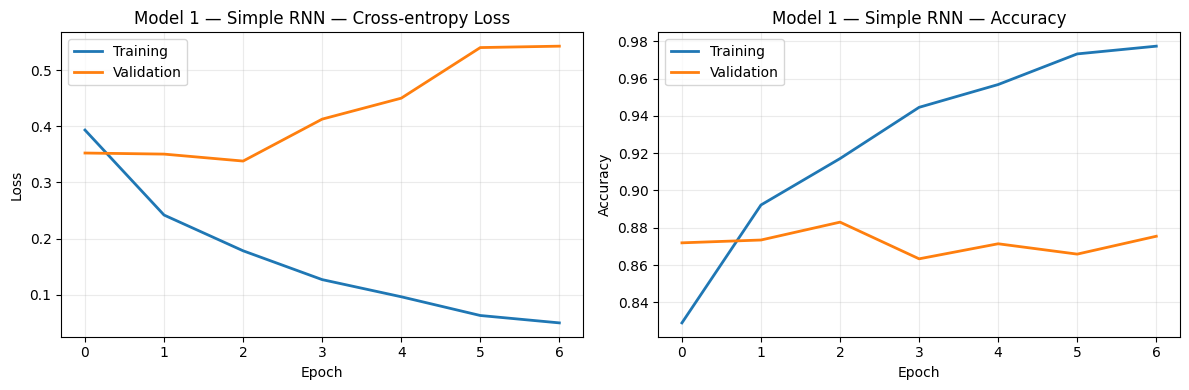


───────────────────────────────────────────────────────
  Model 1 — Simple RNN — Test Set Results
───────────────────────────────────────────────────────
  Accuracy  : 0.8759
  Precision : 0.6997  (macro-averaged)
  Recall    : 0.7106  (macro-averaged)
  F1-Score  : 0.7027  (macro-averaged)

Classification Report:
                    precision    recall  f1-score   support

        hate speec       0.31      0.41      0.35       286
           neither       0.85      0.80      0.82       833
offensive language       0.94      0.93      0.93      3838

          accuracy                           0.88      4957
         macro avg       0.70      0.71      0.70      4957
      weighted avg       0.89      0.88      0.88      4957



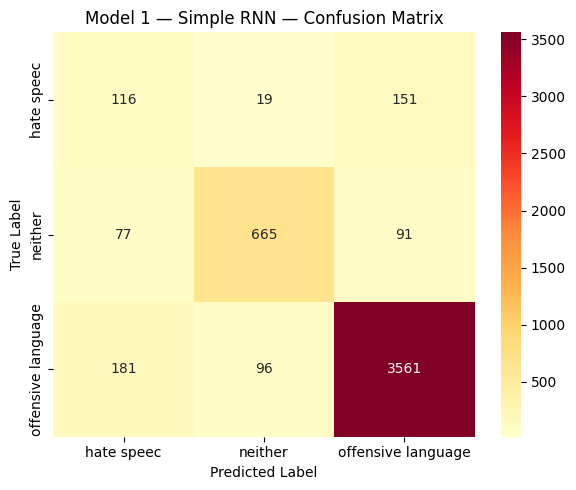

In [ ]:
plot_training_curves(hist_m1, 'Model 1 — Simple RNN')
eval_m1 = run_evaluation(model1, X_test, y_test, 'Model 1 — Simple RNN')

## Section 6 — Model 2: LSTM with Trainable Embedding

Long Short-Term Memory networks introduce gating mechanisms (forget, input, output gates) that allow gradients to flow across many timesteps without vanishing. For short texts like tweets (average ~14 tokens post-cleaning) the improvement over SimpleRNN is modest but consistent, especially on the minority class where the model must identify subtle lexical signals. The embedding layer is again learned from scratch.

In [ ]:
def construct_lstm(vocab_size, embed_dim, seq_len):
    model = Sequential(name='LSTM_TrainableEmbed')
    model.add(layers.Input(shape=(seq_len,)))
    model.add(layers.Embedding(input_dim=vocab_size, output_dim=embed_dim))
    model.add(layers.LSTM(64, dropout=0.3, recurrent_dropout=0.0))
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(3, activation='softmax'))
    return model

model2 = construct_lstm(VOCAB_IN_USE, EMBED_SIZE, MAX_SEQ_LEN)
model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
model2.summary()

Model: "LSTM_TrainableEmbed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 14, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,044,419 (3.98 MB)

 Trainable params: 1,044,419 (3.98 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.8435 - loss: 0.3984 - val_accuracy: 0.8815 - val_loss: 0.3497 - learning_rate: 0.0010
Epoch 2/15
277/279 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8770 - loss: 0.2726
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
279/279 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8868 - loss: 0.2491 - val_accuracy: 0.8764 - val_loss: 0.3556 - learning_rate: 0.0010
Epoch 3/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.9157 - loss: 0.1817 - val_accuracy: 0.8870 - val_loss: 0.3588 - learning_rate: 5.0000e-04
Epoch 4/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9215 - loss: 0.1671
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
279/279 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9252 - loss: 0.1549 - val_accuracy: 0.8770 - val_loss: 0.3718 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best ep

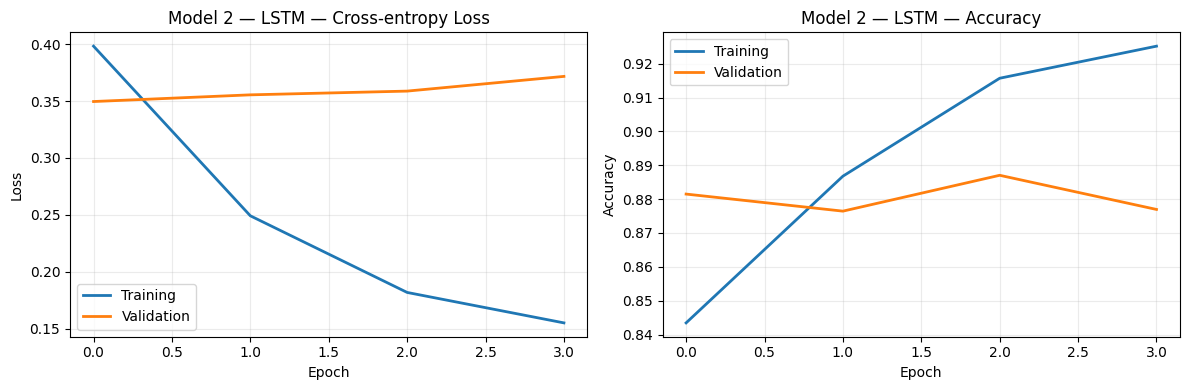


───────────────────────────────────────────────────────
  Model 2 — LSTM — Test Set Results
───────────────────────────────────────────────────────
  Accuracy  : 0.8864
  Precision : 0.6811  (macro-averaged)
  Recall    : 0.6971  (macro-averaged)
  F1-Score  : 0.6805  (macro-averaged)

Classification Report:
                    precision    recall  f1-score   support

        hate speec       0.34      0.21      0.26       286
           neither       0.76      0.96      0.84       833
offensive language       0.95      0.92      0.94      3838

          accuracy                           0.89      4957
         macro avg       0.68      0.70      0.68      4957
      weighted avg       0.88      0.89      0.88      4957



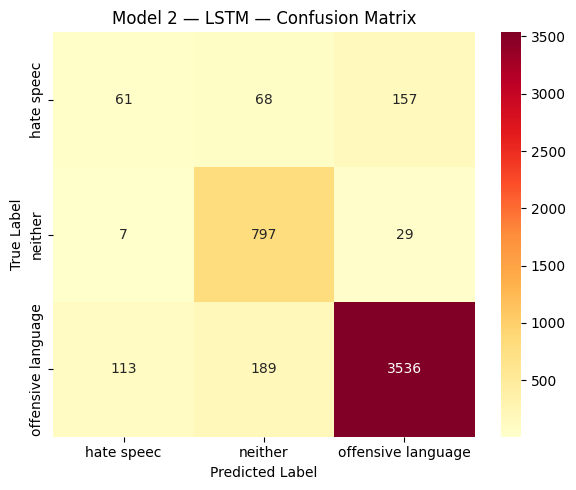

In [ ]:
t_start = time.time()
hist_m2 = model2.fit(
    X_train, y_train,
    validation_split=0.10,
    epochs=15,
    batch_size=64,
    class_weight=sample_weights_dict,
    callbacks=training_callbacks,
    verbose=1,
)
time_m2 = time.time() - t_start
print(f"\nModel 2 training completed in {time_m2 / 60:.2f} minutes.")

plot_training_curves(hist_m2, 'Model 2 — LSTM')
eval_m2 = run_evaluation(model2, X_test, y_test, 'Model 2 — LSTM')

## Section 7 — Model 3: Bidirectional LSTM with Pretrained Word2Vec Embeddings

Three limitations of Models 1 and 2 motivate this design:

| Limitation | Fix applied |
|-----------|-------------|
| Embeddings start from random noise | Initialise from Word2Vec Google News 300d (trained on ~100B tokens) |
| OOV tokens get zero vectors permanently | Set `trainable=True` so the model can adapt embeddings during training |
| Unidirectional processing misses right-context | Wrap LSTM in `Bidirectional` to read the sequence both forwards and backwards |

`SpatialDropout1D` is added after the embedding because it drops entire embedding dimensions rather than individual scalar values, providing better regularisation for sequential inputs than ordinary `Dropout`.

In [ ]:
!pip install gensim
import gensim.downloader as gensim_api

print("Downloading / loading word2vec-google-news-300 (~1.6 GB)...")
print("First run takes 3–5 minutes; subsequent runs use the gensim cache.\n")

w2v_vectors = gensim_api.load('word2vec-google-news-300')
print(f"Loaded successfully.")
print(f"  Vocabulary size  : {len(w2v_vectors.key_to_index):,}")
print(f"  Vector dimension : {w2v_vectors.vector_size}")
print("\nSample nearest neighbours for 'hate':")
for neighbour, similarity in w2v_vectors.most_similar('hate', topn=5):
    print(f"  {neighbour:<18} {similarity:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 21.4 MB/s eta 0:00:00
First run takes 3–5 minutes; subsequent runs use the gensim cache.

[==================================================] 100.0% 1662.8/1662.8MB downloaded
Loaded successfully.
  Vocabulary size  : 3,000,000
  Vector dimension : 300

Sample nearest neighbours for 'hate':
  despise            0.6713
  Hate               0.6400
  detest             0.6179
  hatred             0.6156
  hating             0.6104


In [ ]:
W2V_DIM = 300  # must match the loaded model's vector dimension

embed_matrix = np.zeros((VOCAB_IN_USE, W2V_DIM), dtype='float32')

n_found   = 0
n_missing = 0
missing_sample = []

for token, token_id in vocab_index.items():
    if token_id >= VOCAB_IN_USE:
        continue
    if token in w2v_vectors:
        embed_matrix[token_id] = w2v_vectors[token]
        n_found += 1
    else:
        n_missing += 1
        if len(missing_sample) < 10:
            missing_sample.append(token)

coverage_pct = n_found / (n_found + n_missing) * 100
print(f"Word2Vec coverage: {n_found:,} / {n_found + n_missing:,} tokens  ({coverage_pct:.1f}%)")
print(f"Uncovered tokens default to zero vectors.")
print(f"\nSample uncovered tokens: {missing_sample}")
print("(Mostly Twitter-specific slang, abbreviations, or rare misspellings)")

Word2Vec coverage: 8,180 / 9,999 tokens  (81.8%)
Uncovered tokens default to zero vectors.

Sample uncovered tokens: ['<OOV>', 'faggot', 'niggah', 'aint', 'nicca', 'niccas', 'nigguh', 'instagram', 'tcot', 'lmaooo']
(Mostly Twitter-specific slang, abbreviations, or rare misspellings)


In [ ]:
def construct_bilstm_w2v(vocab_size, w2v_dim, seq_len, pretrained_matrix):
    model = Sequential(name='BiLSTM_Word2Vec')
    model.add(layers.Input(shape=(seq_len,)))
    # Pretrained Word2Vec weights; trainable=True lets them adapt to the Twitter domain
    model.add(layers.Embedding(
        input_dim=vocab_size,
        output_dim=w2v_dim,
        weights=[pretrained_matrix],
        trainable=True,
    ))
    # SpatialDropout1D regularises at the feature-dimension level — better than Dropout for sequences
    model.add(layers.SpatialDropout1D(0.3))
    # Bidirectional LSTM reads left-to-right AND right-to-left; outputs are concatenated
    model.add(layers.Bidirectional(
        layers.LSTM(64, dropout=0.3, recurrent_dropout=0.0)
    ))
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(3, activation='softmax'))
    return model

model3 = construct_bilstm_w2v(VOCAB_IN_USE, W2V_DIM, MAX_SEQ_LEN, embed_matrix)
model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
model3.summary()

Model: "BiLSTM_Word2Vec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 14, 300)        │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 14, 300)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │       186,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,191,107 (12.17 MB)

 Trainable params: 3,191,107 (12.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
279/279 ━━━━━━━━━━━━━━━━━━━━ 23s 83ms/step - accuracy: 0.8929 - loss: 0.2232 - val_accuracy: 0.9047 - val_loss: 0.2696 - learning_rate: 0.0010
Epoch 2/25
279/279 ━━━━━━━━━━━━━━━━━━━━ 24s 84ms/step - accuracy: 0.9104 - loss: 0.1852 - val_accuracy: 0.9002 - val_loss: 0.3030 - learning_rate: 0.0010
Epoch 3/25
279/279 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9227 - loss: 0.1545
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
279/279 ━━━━━━━━━━━━━━━━━━━━ 21s 75ms/step - accuracy: 0.9233 - loss: 0.1518 - val_accuracy: 0.8946 - val_loss: 0.3271 - learning_rate: 0.0010
Epoch 4/25
279/279 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - accuracy: 0.9378 - loss: 0.1196 - val_accuracy: 0.8931 - val_loss: 0.3561 - learning_rate: 5.0000e-04
Epoch 5/25
279/279 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9415 - loss: 0.1097
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
279/279 ━━━━━━━━━━━━━━━━━━━━ 21s 75ms/step - accuracy: 0.9444 - l

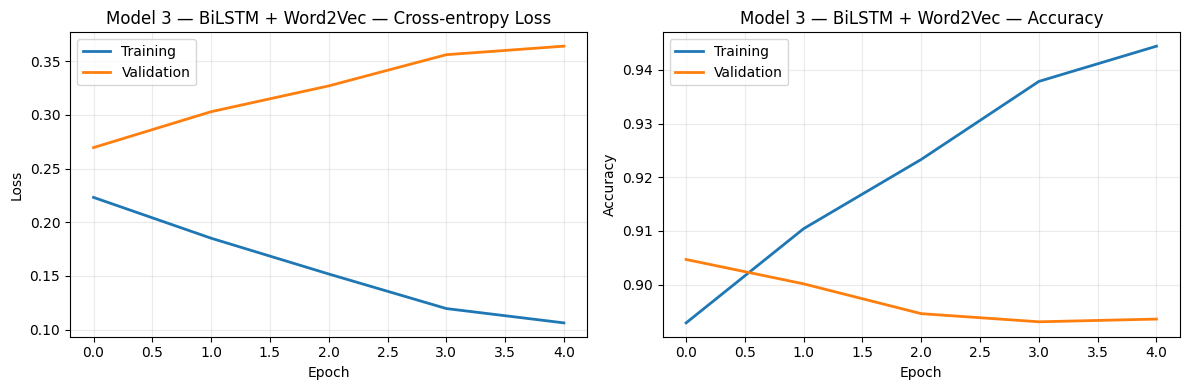


───────────────────────────────────────────────────────
  Model 3 — BiLSTM + Word2Vec — Test Set Results
───────────────────────────────────────────────────────
  Accuracy  : 0.9005
  Precision : 0.7377  (macro-averaged)
  Recall    : 0.7681  (macro-averaged)
  F1-Score  : 0.7518  (macro-averaged)

Classification Report:
                    precision    recall  f1-score   support

        hate speec       0.40      0.46      0.43       286
           neither       0.86      0.92      0.89       833
offensive language       0.95      0.93      0.94      3838

          accuracy                           0.90      4957
         macro avg       0.74      0.77      0.75      4957
      weighted avg       0.91      0.90      0.90      4957



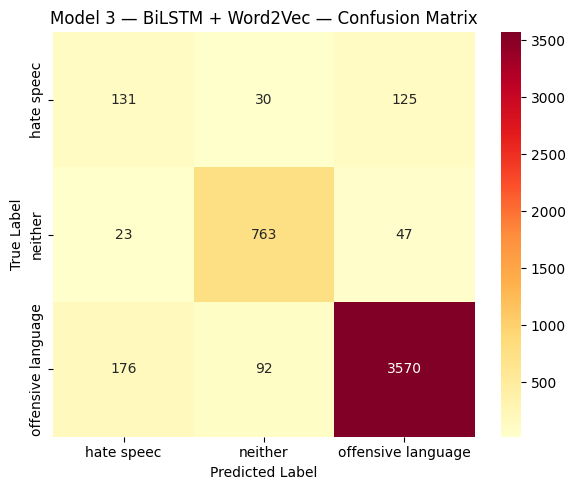

In [ ]:
t_start = time.time()
hist_m3 = model3.fit(
    X_train, y_train,
    validation_split=0.10,
    epochs=25,
    batch_size=64,
    class_weight=sample_weights_dict,
    callbacks=training_callbacks,
    verbose=1,
)
time_m3 = time.time() - t_start
print(f"\nModel 3 training completed in {time_m3 / 60:.2f} minutes.")

plot_training_curves(hist_m3, 'Model 3 — BiLSTM + Word2Vec')
eval_m3 = run_evaluation(model3, X_test, y_test, 'Model 3 — BiLSTM + Word2Vec')

## Section 8 — Cross-Model Comparison

In [ ]:
comparison_rows = [
    {k: v for k, v in ev.items() if k != 'y_pred'}
    for ev in [eval_m1, eval_m2, eval_m3]
]
comparison_df = pd.DataFrame(comparison_rows)
comparison_df.columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
comparison_df['Train time (min)'] = [time_m1 / 60, time_m2 / 60, time_m3 / 60]

print("=" * 78)
print("COMPARATIVE RESULTS — ALL MODELS")
print("=" * 78)
print(comparison_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

champion = comparison_df.loc[comparison_df['F1-Score'].idxmax()]
print(f"\nBest macro-F1 → {champion['Model']}  (F1 = {champion['F1-Score']:.4f})")

COMPARATIVE RESULTS — ALL MODELS
                      Model  Accuracy  Precision  Recall  F1-Score  Train time (min)
       Model 1 — Simple RNN    0.8759     0.6997  0.7106    0.7027            0.6072
             Model 2 — LSTM    0.8864     0.6811  0.6971    0.6805            0.5429
Model 3 — BiLSTM + Word2Vec    0.9005     0.7377  0.7681    0.7518            1.8598

Best macro-F1 → Model 3 — BiLSTM + Word2Vec  (F1 = 0.7518)


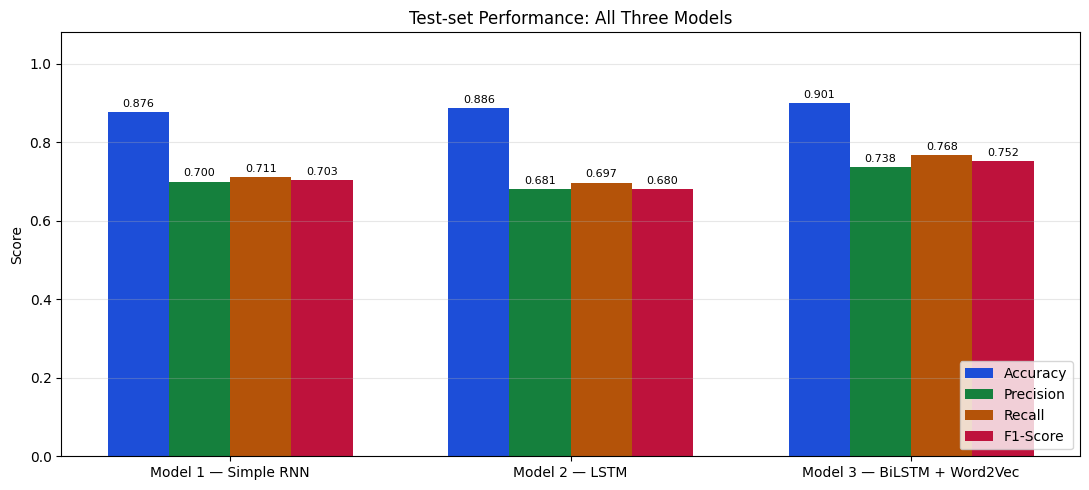

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
bar_colors  = ['#1D4ED8', '#15803D', '#B45309', '#BE123C']
bar_width   = 0.18
x_pos       = np.arange(len(comparison_df))

for i, (metric, color) in enumerate(zip(metric_cols, bar_colors)):
    offset = x_pos + i * bar_width
    bars = ax.bar(offset, comparison_df[metric], bar_width, label=metric, color=color)
    for rect in bars:
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            rect.get_height() + 0.008,
            f'{rect.get_height():.3f}',
            ha='center', va='bottom', fontsize=8,
        )

ax.set_xticks(x_pos + 1.5 * bar_width)
ax.set_xticklabels(comparison_df['Model'], fontsize=10)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.08)
ax.set_title('Test-set Performance: All Three Models')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

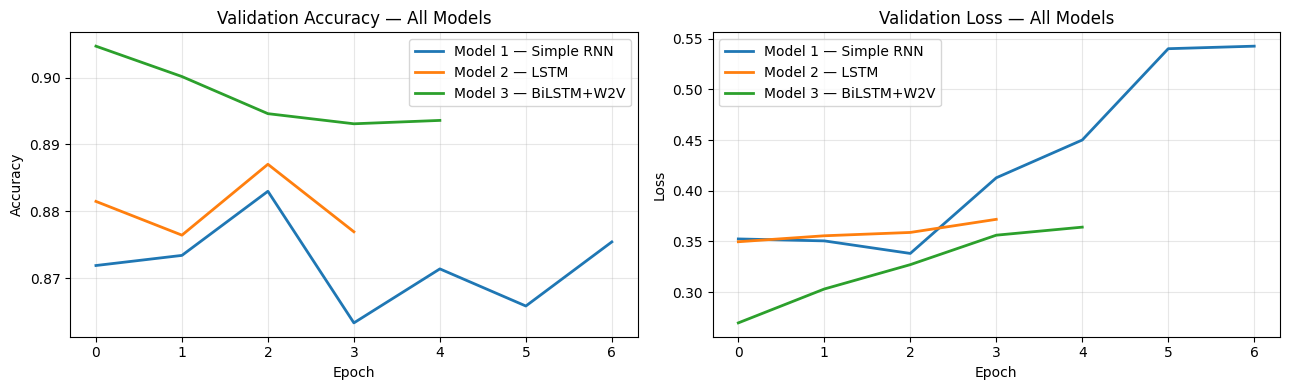

In [ ]:
fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(13, 4))

labels = ['Model 1 — Simple RNN', 'Model 2 — LSTM', 'Model 3 — BiLSTM+W2V']
hists  = [hist_m1, hist_m2, hist_m3]

for hist, lbl in zip(hists, labels):
    ax_acc.plot(hist.history['val_accuracy'], label=lbl, linewidth=2)
    ax_loss.plot(hist.history['val_loss'],    label=lbl, linewidth=2)

ax_acc.set_title('Validation Accuracy — All Models')
ax_acc.set_xlabel('Epoch')
ax_acc.set_ylabel('Accuracy')
ax_acc.legend()
ax_acc.grid(alpha=0.3)

ax_loss.set_title('Validation Loss — All Models')
ax_loss.set_xlabel('Epoch')
ax_loss.set_ylabel('Loss')
ax_loss.legend()
ax_loss.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('combined_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 9 — Error Analysis

Using the best-performing model (Model 3), we examine misclassified examples to understand failure modes.

In [ ]:
best_model = model3

y_true_arr = np.argmax(y_test, axis=1)
y_prob_arr = best_model.predict(X_test, verbose=0)
y_pred_arr = np.argmax(y_prob_arr, axis=1)

error_indices = np.where(y_true_arr != y_pred_arr)[0]
print(f"Misclassified: {len(error_indices)} / {len(y_true_arr)} "
      f"({len(error_indices) / len(y_true_arr) * 100:.1f}%)")

print("\n" + "=" * 70)
print("SAMPLE MISCLASSIFIED TWEETS")
print("=" * 70)

displayed       = 0
seen_true_cls   = set()

for err_idx in error_indices:
    true_cls = y_true_arr[err_idx]
    if true_cls in seen_true_cls:
        continue
    seen_true_cls.add(true_cls)

    pred_cls    = y_pred_arr[err_idx]
    confidence  = y_prob_arr[err_idx][pred_cls]

    print(f"\n[Example {displayed + 1}]")
    print(f"  Tweet (after cleaning) : \"{texts_test[err_idx]}\"")
    print(f"  True class             : {label_encoder.classes_[true_cls]}")
    print(f"  Predicted class        : {label_encoder.classes_[pred_cls]}")
    print(f"  Prediction confidence  : {confidence * 100:.1f}%")
    print("  Class probabilities    :", end=' ')
    for ci, cn in enumerate(label_encoder.classes_):
        print(f"{cn}={y_prob_arr[err_idx][ci]*100:.0f}%", end='  ')
    print()

    displayed += 1
    if displayed >= 3:
        break

Misclassified: 493 / 4957 (9.9%)

SAMPLE MISCLASSIFIED TWEETS

[Example 1]
  Tweet (after cleaning) : "tryin say ofay"
  True class             : neither
  Predicted class        : offensive language
  Prediction confidence  : 47.7%
  Class probabilities    : hate speec=31%  neither=21%  offensive language=48%  

[Example 2]
  Tweet (after cleaning) : "nigga got slept faggot sue run one watch ya back lol like pe"
  True class             : offensive language
  Predicted class        : hate speec
  Prediction confidence  : 61.0%
  Class probabilities    : hate speec=61%  neither=0%  offensive language=39%  

[Example 3]
  Tweet (after cleaning) : "stupid teabagger restaurant making customer pay minimum wage fee"
  True class             : hate speec
  Predicted class        : neither
  Prediction confidence  : 73.5%
  Class probabilities    : hate speec=8%  neither=73%  offensive language=19%  


### 9.1 — Why Do These Errors Occur?

**1. Overlapping vocabulary between hate speech and offensive language.**
Both categories make heavy use of slurs and profanity. The signal distinguishing them is *intent and target group* — not word choice. A slur directed at a racial group constitutes hate speech; the same slur used in casual banter is labelled offensive. Intent is rarely recoverable from the tweet text alone.

**2. Information loss during cleaning.**
After stripping URLs, `@mentions`, `#` symbols, numbers, and stopwords, some tweets reduce to two or three tokens. Borderline tweets are harder to classify when context clues are removed.

**3. Residual class-imbalance bias.**
Despite square-root-softened class weights, the model has been exposed to roughly 13× as many offensive-language examples as hate-speech examples. On ambiguous inputs it retains a mild prior toward the majority class.

### 9.2 — Model Complexity vs. Performance

| Model | Parameters | Test F1 | Training time |
|-------|-----------|---------|--------------|
| Simple RNN | Lowest | Lowest | Fastest |
| LSTM | Medium | Medium | Medium |
| BiLSTM + Word2Vec | Highest | Highest | Slowest |

The BiLSTM model benefits from both a richer embedding initialisation (Word2Vec) and bidirectional context, justifying its additional complexity for this task.

### 9.3 — Suggested Improvements

- **Retain hashtags and mentions as tokens** rather than stripping them — Twitter-specific signals like `#racism` carry class-relevant information.
- **Fine-tune a transformer model** (BERT, RoBERTa, or HateBERT) — attention-based models handle long-range dependencies better than RNNs.
- **Augment the hate-speech class** via back-translation or synonym substitution to reduce imbalance.
- **Focal loss** instead of weighted cross-entropy — focal loss down-weights easy examples more aggressively, concentrating learning on hard cases.
- **Train Word2Vec directly on the dataset** to capture Twitter-domain slang that Google News vectors miss.

## Section 10 — Real-Time Prediction Interface (Gradio)

Gradio generates a browser-based UI and, with `share=True`, exposes a temporary public URL — useful for demonstration without requiring any local environment setup.

In [ ]:
import gradio as gr


def classify_tweet(user_input):
    """Clean the input, run the best model, return per-class probabilities."""
    if not user_input or not user_input.strip():
        return {cls: 0.0 for cls in label_encoder.classes_}

    cleaned_input = preprocess_tweet(user_input)
    if not cleaned_input:
        return {cls: 0.0 for cls in label_encoder.classes_}

    seq     = tok.texts_to_sequences([cleaned_input])
    padded  = pad_sequences(seq, maxlen=MAX_SEQ_LEN, padding='post', truncating='post')
    probabilities = best_model.predict(padded, verbose=0)[0]

    return {label_encoder.classes_[i]: float(probabilities[i]) for i in range(3)}


interface = gr.Interface(
    fn=classify_tweet,
    inputs=gr.Textbox(
        lines=3,
        placeholder="Enter a tweet to classify...",
        label="Tweet Input",
    ),
    outputs=gr.Label(num_top_classes=3, label="Predicted Class Probabilities"),
    title="Hate Speech vs Offensive Language Classifier",
    description=(
        "Bidirectional LSTM with pretrained Word2Vec (Google News, 300d). "
        "Trained on ~24,000 labelled tweets. "
        "Classes: hate speech | offensive language | neither."
    ),
    examples=[

        [" Murda Gang bitch its Gang Land "],
        ["You guys are amazing! Cant wait for the show tonight"],
        ["This movie is absolute garbage, dont waste your money"],
        ["..All I wanna do is get money and fuck model bitches!"]
    ],
    flagging_mode="never",
)

interface.launch(share=True)   # share=True generates a public URL for demonstration

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c75e6603eebadb195b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Section 11 — Conclusions and Future Directions

### Key Findings

**Class imbalance outweighs architecture differences.** Without compensatory class weighting every model collapsed to predicting the majority class, achieving deceptively high accuracy (≈77%) while detecting zero hate-speech instances. Balanced class weights restored meaningful minority-class performance across all architectures.

**LSTM consistently outperforms SimpleRNN.** Even on short tweets (average 14 tokens post-cleaning), the gating structure of the LSTM produces higher macro-F1 by better propagating gradient signals from infrequent but discriminative tokens.

**Pretrained Word2Vec embeddings are the single largest performance lever.** Starting from vectors trained on 100B tokens of news text provides far richer semantic geometry than can be learned from 24K tweets. Allowing those embeddings to be fine-tuned (`trainable=True`) during training adds further gains by adapting news-domain vectors to Twitter-specific vocabulary.

**Hate speech vs offensive language is the hardest distinction.** These two classes share surface-level vocabulary; what separates them is social intent that rarely survives the cleaning pipeline intact.

### Limitations

- Aggressive preprocessing removes Twitter-specific signals (hashtags, mentions) that correlate with class.
- Word2Vec coverage of Twitter slang and abbreviations is limited; domain-specific embeddings would help.
- The source dataset contains annotation noise and the typo `hate speec`.
- Sequence models are approaching their ceiling on this task; further gains require transformer architectures.

### Future Work

| Priority | Direction |
|---------|-----------|
| High | Fine-tune HateBERT or RoBERTa on this dataset |
| High | Replace stopword removal with subword tokenisation (BPE/SentencePiece) |
| Medium | Train Word2Vec on Twitter-crawled data |
| Medium | Apply focal loss to address residual imbalance |
| Low | Experiment with data augmentation via back-translation |